In [9]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
from transformers import AutoImageProcessor, YolosForObjectDetection

# 1. YOLOS 모델 로딩
processor = AutoImageProcessor.from_pretrained("valentinafeve/yolos-fashionpedia")
model = YolosForObjectDetection.from_pretrained("valentinafeve/yolos-fashionpedia")

# 2. 클래스 총 개수 (Fashionpedia: 46개 클래스)
NUM_CLASSES = len(model.config.id2label)

# 3. 스타일 점수 계산 함수 (단순 rule 기반)
def compute_style_score(results, class_folder):
    accessory_ids = {
        13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
        23, 24, 25, 26, 34, 35, 36, 37, 38, 39,
        40, 41, 42, 43, 44, 45
    }
    acc_count = sum(1 for label in results['labels'] if label.item() in accessory_ids)
    total_count = len(results['labels'])

    acc_ratio = acc_count / total_count if total_count > 0 else 0
    score_raw = acc_ratio * 0.7 + min(total_count / 10, 1.0) * 0.3  # 기본 [0, 1]

    # 범위 조정
    if class_folder == "maximal":
        score = round(abs(score_raw), 3)
    else:  # minimal
        score = round(-abs(score_raw), 3)


    return score

# 4. YOLOS 벡터 추출 함수 (46차원)
def get_yolos_vector(results):
    vec = np.zeros(NUM_CLASSES)
    for label in results['labels']:
        vec[label.item()] += 1
    return vec

# 5. 전체 이미지에 대해 라벨링 수행
def label_all_images(dataset_root='dataset', output_csv='style_core_labels.csv'):
    data = []

    for class_folder in ['minimal', 'maximal']:
        folder_path = os.path.join(dataset_root, class_folder)
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

        for img_name in image_files:
            img_path = os.path.join(folder_path, img_name)
            try:
                image = Image.open(img_path).convert("RGB")
                inputs = processor(images=image, return_tensors="pt")
                outputs = model(**inputs)

                target_sizes = torch.tensor([image.size[::-1]])
                results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

                if len(results['labels']) == 0:
                    print(f"⚠️ No detection in {img_name}, skipping...")
                    continue

                # style_core 점수 및 벡터
                score = compute_style_score(results, class_folder)
                vector = get_yolos_vector(results)

                # 저장
                data.append({
                    'filename': img_name,
                    'folder': class_folder,
                    'style_core': score,
                    **{f'class_{i}': int(vector[i]) for i in range(NUM_CLASSES)}
                })

            except Exception as e:
                print(f"❌ Error processing {img_name}: {e}")
                continue

    # 저장
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"\n✅ 총 {len(df)}개 이미지 라벨링 완료 → '{output_csv}' 저장됨.")

# 6. 실행
if __name__ == '__main__':
    label_all_images()



✅ 총 100개 이미지 라벨링 완료 → 'style_core_labels.csv' 저장됨.



🚀 모델: Random Forest

📊 [Validation] 성능 지표 - Random Forest:
🔸 MAE: 0.5598 | RMSE: 0.7448 | R²: -0.4959 | Pearson: 0.2153

📊 [Test] 성능 지표 - Random Forest:
🔸 MAE: 0.4301 | RMSE: 0.6169 | R²: -0.1572 | Pearson: 0.2298

🚀 모델: Gradient Boosting

📊 [Validation] 성능 지표 - Gradient Boosting:
🔸 MAE: 0.6664 | RMSE: 0.8785 | R²: -1.0812 | Pearson: 0.1313

📊 [Test] 성능 지표 - Gradient Boosting:
🔸 MAE: 0.4959 | RMSE: 0.6713 | R²: -0.3702 | Pearson: 0.0716

🚀 모델: XGBoost

📊 [Validation] 성능 지표 - XGBoost:
🔸 MAE: 0.5870 | RMSE: 0.8159 | R²: -0.7953 | Pearson: 0.2568

📊 [Test] 성능 지표 - XGBoost:
🔸 MAE: 0.4869 | RMSE: 0.7151 | R²: -0.5550 | Pearson: 0.1342

🚀 모델: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 

c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


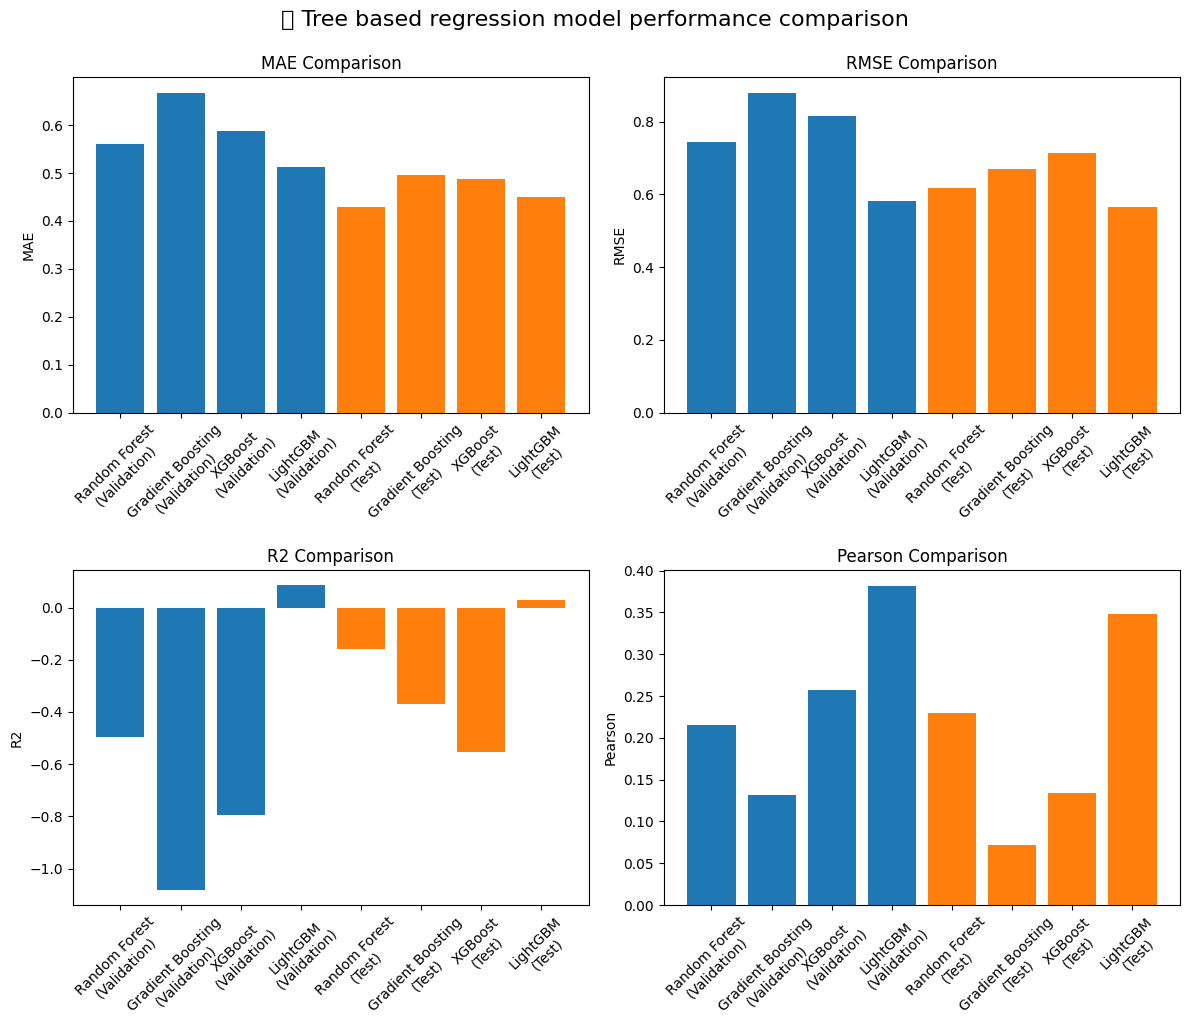

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# --- 1. 데이터 로딩 ---
df = pd.read_csv("style_core_labels.csv")
X = df[[f'class_{i}' for i in range(46)]].values
y = df['style_core'].values

# --- 2. 데이터 분할 (8:1:1) ---
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# --- 3. 성능 저장용 딕셔너리 ---
results = {
    'Model': [],
    'Set': [],
    'MAE': [],
    'RMSE': [],
    'R2': [],
    'Pearson': []
}

# --- 4. 평가 함수 ---
def evaluate(model, X, y, dataset_name, model_name):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    pearson, _ = pearsonr(y, preds)

    results['Model'].append(model_name)
    results['Set'].append(dataset_name)
    results['MAE'].append(mae)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['Pearson'].append(pearson)

    print(f"\n📊 [{dataset_name}] 성능 지표 - {model_name}:")
    print(f"🔸 MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | Pearson: {pearson:.4f}")

# --- 5. 모델 정의 ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

# --- 6. 학습 및 평가 ---
for name, model in models.items():
    print(f"\n🚀 모델: {name}")
    model.fit(X_train, y_train)
    evaluate(model, X_val, y_val, "Validation", name)
    evaluate(model, X_test, y_test, "Test", name)

# --- 7. 결과 시각화 ---
results_df = pd.DataFrame(results)

metrics = ['MAE', 'RMSE', 'R2', 'Pearson']
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i, metric in enumerate(metrics):
    ax = axs[i]
    for dataset in ['Validation', 'Test']:
        subset = results_df[results_df['Set'] == dataset]
        ax.bar(
            [f"{m}\n({dataset})" for m in subset['Model']],
            subset[metric],
            label=dataset
        )
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle("📈 Tree based regression model performance comparison", fontsize=16, y=1.03)
plt.show()


In [18]:
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from lightgbm import LGBMRegressor

# 데이터 로딩
df = pd.read_csv("style_core_labels.csv")
X = df[[f'class_{i}' for i in range(46)]].values
y = df['style_core'].values

# 데이터 분할 (Train/Val/Test = 8:1:1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 모델 정의 및 학습
model = LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 평가 함수
def evaluate(model, X, y, name):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    pearson, _ = pearsonr(y, preds)
    print(f"\n📊 [{name}] 성능 지표:")
    print(f"🔸 MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | Pearson: {pearson:.4f}")
    return preds

# 성능 평가
evaluate(model, X_val, y_val, "Validation")
evaluate(model, X_test, y_test, "Test")

# 모델 저장
joblib.dump(model, "lightgbm_style_model.pkl")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 7
[LightGBM] [Info] Start training from score 0.155450
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


['lightgbm_style_model.pkl']

In [ ]:
from transformers import AutoImageProcessor, YolosForObjectDetection
import joblib
from PIL import Image
import torch
import numpy as np

# 1. YOLOS 로드
processor = AutoImageProcessor.from_pretrained("valentinafeve/yolos-fashionpedia")
model_yolos = YolosForObjectDetection.from_pretrained("valentinafeve/yolos-fashionpedia")

# 2. LightGBM 모델 로드
model_lgbm = joblib.load("lightgbm_style_model.pkl")

# 3. YOLOS 감지 결과 → 벡터 변환 함수
def get_yolos_vector(results):
    vec = np.zeros(46, dtype=np.float32)  # class_0 ~ class_45
    for label in results["labels"]:
        class_id = int(label)
        if 0 <= class_id < 46:
            vec[class_id] += 1
    return vec

# 4. 스타일 점수 예측 함수
def predict_score_from_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    outputs = model_yolos(**inputs)

    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(
        outputs, target_sizes=target_sizes, threshold=0.5
    )[0]

    if len(results["labels"]) == 0:
        print("No objects detected.")
        return None

    vec = get_yolos_vector(results)  # 46차원 벡터
    score = model_lgbm.predict([vec])[0]  # 예측
    return score

# 5. 예시 실행
score = predict_score_from_image("dataset/test_image.png")
if score is not None:
    print(f"예측된 스타일 점수: {score:.3f}")


🎯 예측된 스타일 점수: 0.301


c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [22]:
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import AutoImageProcessor, YolosForObjectDetection
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr


# YOLOS
processor = AutoImageProcessor.from_pretrained("valentinafeve/yolos-fashionpedia")
model_yolos = YolosForObjectDetection.from_pretrained("valentinafeve/yolos-fashionpedia")

# LightGBM 
model_lgbm = joblib.load("lightgbm_style_model.pkl")  # 학습된 모델

# 아이템 종류와 개수 기준 (악세사리 + 전체 아이템 수)
def compute_style_score_rule_based(results):
    accessory_ids = {
        13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
        23, 24, 25, 26, 34, 35, 36, 37, 38, 39,
        40, 41, 42, 43, 44, 45
    }
    acc_count = sum(1 for label in results["labels"] if label.item() in accessory_ids)
    total_count = len(results["labels"])

    acc_ratio = acc_count / total_count if total_count > 0 else 0
    score_raw = acc_ratio * 0.7 + min(total_count / 10, 1.0) * 0.3  # [0, 1]

    if acc_count >= 2:
        return round(score_raw, 3)      # Maximal: 양수
    else:
        return round(score_raw * -1, 3) # Minimal: 음수


def get_yolos_vector(results):
    vec = np.zeros(46, dtype=np.float32)
    for label in results["labels"]:
        class_id = int(label)
        if 0 <= class_id < 46:
            vec[class_id] += 1
    return vec

def predict_scores_from_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    outputs = model_yolos(**inputs)

    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

    if len(results["labels"]) == 0:
        print("❌ No objects detected.")
        return None, None

    # 1. Rule 기반 점수
    rule_score = compute_style_score_rule_based(results)

    # 2. LightGBM 예측
    vec = get_yolos_vector(results)
    lgbm_score = model_lgbm.predict([vec])[0]

    return rule_score, lgbm_score


image_path = "dataset/test_image.png"
rule, ml = predict_scores_from_image(image_path)

if rule is not None and ml is not None:
    print(f" Rule 기반 점수: {rule:.3f}")
    print(f" LightGBM 예측 점수: {ml:.3f}")

    # 비교 판단
    if abs(ml) > abs(rule):
        print("LightGBM이 더 확신 있는 스타일 점수를 부여했습니다.")
    else:
        print("Rule 기반 점수가 더 극단적인 스타일로 판단했습니다.")



 Rule 기반 점수: 0.738
 LightGBM 예측 점수: 0.301
Rule 기반 점수가 더 극단적인 스타일로 판단했습니다.


c:\Users\minseong\anaconda3\envs\fashion\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [24]:
# 클래스 ID → 클래스명 매핑 딕셔너리 출력
from transformers import YolosForObjectDetection

model = YolosForObjectDetection.from_pretrained("valentinafeve/yolos-fashionpedia")

print(model.config.id2label)

{0: 'shirt, blouse', 1: 'top, t-shirt, sweatshirt', 2: 'sweater', 3: 'cardigan', 4: 'jacket', 5: 'vest', 6: 'pants', 7: 'shorts', 8: 'skirt', 9: 'coat', 10: 'dress', 11: 'jumpsuit', 12: 'cape', 13: 'glasses', 14: 'hat', 15: 'headband, head covering, hair accessory', 16: 'tie', 17: 'glove', 18: 'watch', 19: 'belt', 20: 'leg warmer', 21: 'tights, stockings', 22: 'sock', 23: 'shoe', 24: 'bag, wallet', 25: 'scarf', 26: 'umbrella', 27: 'hood', 28: 'collar', 29: 'lapel', 30: 'epaulette', 31: 'sleeve', 32: 'pocket', 33: 'neckline', 34: 'buckle', 35: 'zipper', 36: 'applique', 37: 'bead', 38: 'bow', 39: 'flower', 40: 'fringe', 41: 'ribbon', 42: 'rivet', 43: 'ruffle', 44: 'sequin', 45: 'tassel'}
